# Imports & Data Load

## Imports

In [1]:
!pip install xgboost

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

from src.db import run_query
from src.features import get_feature_columns, get_target_columns

## Load from DuckDB

In [2]:
df = run_query("SELECT * FROM analytics.model_features").copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["city", "time"]).reset_index(drop=True)

print(df.shape)
df.head()

(10955, 20)


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,day_of_month,temperature_lag_1,precipitation_lag_1,wind_lag_1,humidity_lag_1,temperature_3d_avg,precipitation_7d_sum,wind_3d_avg,humidity_7d_avg,city_encoded
0,2020-01-02,8.6,0.0,33.0,88,50,3.2,30162.88,Baku,1,2,11.4,0.0,11.4,90.0,10.000000,0.0,22.200000,89.000000,0
1,2020-01-03,7.6,1.7,24.1,83,96,3.3,1147.69,Baku,1,3,8.6,0.0,33.0,88.0,9.200000,1.7,22.833333,87.000000,0
2,2020-01-04,8.4,0.2,22.7,83,98,4.6,1300.71,Baku,1,4,7.6,1.7,24.1,83.0,8.200000,1.9,26.600000,86.000000,0
3,2020-01-05,7.7,2.6,12.6,91,100,6.4,0.00,Baku,1,5,8.4,0.2,22.7,83.0,7.900000,4.5,19.800000,87.000000,0
4,2020-01-06,9.8,0.0,9.5,91,65,7.7,30867.98,Baku,1,6,7.7,2.6,12.6,91.0,8.633333,4.5,14.933333,87.666667,0


# Train / Calib / Test Split

## Time-based split

In [3]:
train_end = "2024-07-01"
calib_end = "2025-01-01"
test_start = calib_end

train_df = df[df["time"] < train_end].copy()
calib_df = df[(df["time"] >= train_end) & (df["time"] < calib_end)].copy()
test_df = df[df["time"] >= test_start].copy()

feature_cols = get_feature_columns()
target_cols = get_target_columns()

X_train = train_df[feature_cols]
y_train = train_df[target_cols]

X_calib = calib_df[feature_cols]
y_calib = calib_df[target_cols]

X_test = test_df[feature_cols]
y_test = test_df[target_cols]

print("Train:", X_train.shape, y_train.shape)
print("Calib:", X_calib.shape, y_calib.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (8210, 13) (8210, 5)
Calib: (920, 13) (920, 5)
Test : (1825, 13) (1825, 5)


# Helper Functions

## Supervised maker

In [4]:
def make_supervised(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    out = df.copy().sort_values(["city", "time"]).reset_index(drop=True)
    
    for col in get_target_columns():
        out[f"{col}_target"] = out.groupby("city")[col].shift(-horizon)
    
    out = out.dropna().reset_index(drop=True)
    return out

## Metric evaluator

In [5]:
def evaluate_multitarget(y_true: pd.DataFrame, y_pred: np.ndarray, target_names):
    rows = []
    for i, target in enumerate(target_names):
        yt = y_true.iloc[:, i]
        yp = y_pred[:, i]
        rows.append({
            "target": target,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
        })
    return pd.DataFrame(rows)

## Interval helper

In [6]:
def interval_from_residuals(preds: np.ndarray, residuals: np.ndarray, alpha: float = 0.80):
    """
    Empirical prediction interval.
    alpha=0.80 means target ~80% coverage.
    """
    lower_q = (1 - alpha) / 2
    upper_q = 1 - lower_q

    lower_shift = np.quantile(residuals, lower_q, axis=0)
    upper_shift = np.quantile(residuals, upper_q, axis=0)

    lower = preds + lower_shift
    upper = preds + upper_shift
    return lower, upper

## Plotting helpers

In [7]:
def coverage_score(y_true: np.ndarray, lower: np.ndarray, upper: np.ndarray):
    within = (y_true >= lower) & (y_true <= upper)
    return within.mean(axis=0), within.mean()


def plot_actual_pred_with_interval(
    dates,
    y_true,
    preds,
    lower,
    upper,
    target_idx=0,
    title="Actual vs Predicted with Interval",
    pred_name="Prediction"
):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=dates,
        y=y_true.iloc[:, target_idx],
        mode="lines",
        name="Actual",
        line=dict(width=3)
    ))

    fig.add_trace(go.Scatter(
        x=dates,
        y=preds[:, target_idx],
        mode="lines",
        name=pred_name,
        line=dict(dash="dash")
    ))

    fig.add_trace(go.Scatter(
        x=dates,
        y=upper[:, target_idx],
        line=dict(width=0),
        showlegend=False
    ))

    fig.add_trace(go.Scatter(
        x=dates,
        y=lower[:, target_idx],
        fill="tonexty",
        name="Interval",
        opacity=0.2,
        line=dict(width=0)
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Date",
        yaxis_title=get_target_columns()[target_idx],
        template="plotly_white",
        width=1000,
        height=450,
        hovermode="x unified",
    )
    fig.show()


def plot_residuals(y_true: pd.DataFrame, preds: np.ndarray, target_names, title_prefix="Residuals"):
    residuals = y_true.values - preds

    fig, axes = plt.subplots(len(target_names), 1, figsize=(10, 3 * len(target_names)))
    if len(target_names) == 1:
        axes = [axes]

    for i, target in enumerate(target_names):
        axes[i].hist(residuals[:, i], bins=40)
        axes[i].axvline(0, linestyle="--")
        axes[i].set_title(f"{title_prefix}: {target}")
        axes[i].set_xlabel("Residual")
        axes[i].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


def plot_target_metrics(metrics_df, title="Per-target errors"):
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(metrics_df["target"]))
    width = 0.25

    ax.bar(x - width, metrics_df["MAE"], width, label="MAE")
    ax.bar(x, metrics_df["RMSE"], width, label="RMSE")
    ax.bar(x + width, metrics_df["R2"], width, label="R2")

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_df["target"], rotation=20, ha="right")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Model Dictionary

## All models

In [8]:
models = {
    "Dummy": MultiOutputRegressor(DummyRegressor(strategy="mean")),
    "Ridge": MultiOutputRegressor(Ridge(alpha=1.0)),
    "RandomForest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    ),
    "ExtraTrees": MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    ),
    "GradientBoosting": MultiOutputRegressor(
        GradientBoostingRegressor(random_state=42)
    ),
    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
        )
    ),
}

# Horizon Experiments

## Run 7-day and 28-day experiments

In [9]:
def run_horizon_experiment(df_input: pd.DataFrame, horizon: int, split_date: str):
    df_sup = make_supervised(df_input, horizon=horizon)

    train = df_sup[df_sup["time"] < split_date].copy()
    test = df_sup[df_sup["time"] >= split_date].copy()

    X_train_h = train[feature_cols]
    y_train_h = train[[f"{c}_target" for c in target_cols]]

    X_test_h = test[feature_cols]
    y_test_h = test[[f"{c}_target" for c in target_cols]]

    results = []
    target_results = {}
    preds_dict = {}

    for name, model in models.items():
        print(f"Training {name} for horizon={horizon}...")
        model.fit(X_train_h, y_train_h)
        preds = model.predict(X_test_h)

        preds_dict[name] = preds

        per_target = evaluate_multitarget(y_test_h, preds, [f"{c}_target" for c in target_cols])
        target_results[name] = per_target

        results.append({
            "model": name,
            "horizon": horizon,
            "MAE": per_target["MAE"].mean(),
            "RMSE": per_target["RMSE"].mean(),
            "R2": per_target["R2"].mean(),
        })

    results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
    return df_sup, test, y_test_h, preds_dict, results_df, target_results

In [10]:
def train_best_horizon_model(df_input, horizon, split_date, model_name):
    """
    Train selected model for a specific forecast horizon.
    Returns supervised df, train df, test df, y_test, predictions, model.
    """
    df_sup = make_supervised(df_input, horizon=horizon)

    train = df_sup[df_sup["time"] < split_date].copy()
    test = df_sup[df_sup["time"] >= split_date].copy()

    horizon_target_cols = [f"{c}_target" for c in get_target_columns()]

    X_train_h = train[get_feature_columns()]
    y_train_h = train[horizon_target_cols]

    X_test_h = test[get_feature_columns()]
    y_test_h = test[horizon_target_cols]

    model = models[model_name]
    model.fit(X_train_h, y_train_h)

    preds = model.predict(X_test_h)

    return df_sup, train, test, y_test_h, preds, model

In [11]:
def build_plot_df(test_df, y_test, preds, lower=None, upper=None):
    """
    Builds one clean dataframe for plotting.
    Keeps actual, predicted, lower, upper together.
    """
    plot_df = test_df[["time", "city"]].copy().reset_index(drop=True)

    target_base_cols = get_target_columns()
    target_cols_h = [f"{c}_target" for c in target_base_cols]

    for i, target in enumerate(target_base_cols):
        plot_df[f"{target}_actual"] = y_test.iloc[:, i].reset_index(drop=True)
        plot_df[f"{target}_pred"] = preds[:, i]

        if lower is not None and upper is not None:
            plot_df[f"{target}_lower"] = lower[:, i]
            plot_df[f"{target}_upper"] = upper[:, i]

    return plot_df

In [12]:
split_date = "2025-01-01"

df_7d, test_7d, y_test_7d, preds_7d, results_7d, target_results_7d = run_horizon_experiment(
    df, horizon=7, split_date=split_date
)

df_28d, test_28d, y_test_28d, preds_28d, results_28d, target_results_28d = run_horizon_experiment(
    df, horizon=28, split_date=split_date
)

print("7-day results")
display(results_7d)

print("28-day results")
display(results_28d)

Training Dummy for horizon=7...
Training Ridge for horizon=7...
Training RandomForest for horizon=7...
Training ExtraTrees for horizon=7...
Training GradientBoosting for horizon=7...
Training XGBoost for horizon=7...
Training Dummy for horizon=28...
Training Ridge for horizon=28...
Training RandomForest for horizon=28...
Training ExtraTrees for horizon=28...
Training GradientBoosting for horizon=28...
Training XGBoost for horizon=28...
7-day results


,model,horizon,MAE,RMSE,R2
0,GradientBoosting,7,9.241522,11.702731,0.279991
1,ExtraTrees,7,9.395065,11.960669,0.236076
2,XGBoost,7,9.442263,12.077846,0.230328
3,RandomForest,7,9.539789,12.114021,0.214638
4,Ridge,7,9.676301,12.122957,0.253230
5,Dummy,7,11.595911,14.099264,-0.012680


28-day results


,model,horizon,MAE,RMSE,R2
0,GradientBoosting,28,9.224064,11.721418,0.269036
1,XGBoost,28,9.299589,11.948083,0.236003
2,ExtraTrees,28,9.490799,12.088974,0.211061
3,RandomForest,28,9.539864,12.106741,0.213535
4,Ridge,28,10.265960,12.766842,0.180511
5,Dummy,28,11.505167,14.069378,-0.009690


# Model Selection

## Pick best model

In [13]:
best_model_name = results_7d.iloc[0]["model"]   # можно заменить на results_28d.iloc[0]["model"]
print("Best model by 7-day RMSE:", best_model_name)

best_model = models[best_model_name]

Best model by 7-day RMSE: GradientBoosting


# Prediction interval (80%)

In [14]:
# обучаем лучшую модель на train
best_model.fit(X_train, y_train)

# калибровочные предсказания
calib_preds = best_model.predict(X_calib)
calib_residuals = y_calib.values - calib_preds

# тестовые предсказания
test_preds = best_model.predict(X_test)

# интервалы под целевое покрытие 80%
lower_80, upper_80 = interval_from_residuals(test_preds, calib_residuals, alpha=0.80)

per_target_cov, overall_cov = coverage_score(y_test.values, lower_80, upper_80)

print("Per-target coverage:", per_target_cov)
print("Overall coverage:", overall_cov)

Per-target coverage: [0.75452055 0.85424658 0.79835616 0.75506849 0.73972603]
Overall coverage: 0.7803835616438356


# Visualisation 

In [15]:
def plot_forecast_line(
    plot_df,
    city="Baku",
    target="temperature_2m_max",
    title=None,
    last_n=None
):
    """
    Clean actual vs predicted plot for one city and one target.
    Actual = solid line.
    Prediction = dashed line.
    Interval = shaded area if available.
    """
    city_df = plot_df[plot_df["city"] == city].copy()
    city_df = city_df.sort_values("time")

    if last_n is not None:
        city_df = city_df.tail(last_n)

    actual_col = f"{target}_actual"
    pred_col = f"{target}_pred"
    lower_col = f"{target}_lower"
    upper_col = f"{target}_upper"

    plt.figure(figsize=(14, 5))

    plt.plot(
        city_df["time"],
        city_df[actual_col],
        label="Actual",
        linewidth=2.5
    )

    plt.plot(
        city_df["time"],
        city_df[pred_col],
        label="Predicted",
        linestyle="--",
        linewidth=2
    )

    if lower_col in city_df.columns and upper_col in city_df.columns:
        plt.fill_between(
            city_df["time"],
            city_df[lower_col],
            city_df[upper_col],
            alpha=0.2,
            label="Prediction interval"
        )

    plt.title(title or f"{city} — {target}")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [16]:
def horizon_interval_and_coverage(train_df, test_df, y_test, preds, model, alpha=0.85):
    """
    Build intervals using residuals from the train part.
    """
    horizon_target_cols = [f"{c}_target" for c in get_target_columns()]

    X_train_h = train_df[get_feature_columns()]
    y_train_h = train_df[horizon_target_cols]

    train_preds = model.predict(X_train_h)
    residuals = y_train_h.values - train_preds

    lower, upper = interval_from_residuals(preds, residuals, alpha=alpha)

    per_target_cov, overall_cov = coverage_score(y_test.values, lower, upper)

    coverage_df = pd.DataFrame({
        "target": get_target_columns(),
        "coverage": per_target_cov
    })

    return lower, upper, coverage_df, overall_cov

Best 7-day model: GradientBoosting
7-day coverage:


,target,coverage
0,temperature_2m_max,0.772626
1,precipitation_sum,0.828492
2,wind_speed_10m_max,0.782682
3,relative_humidity_2m_mean,0.826816
4,cloud_cover_mean,0.790503


Overall 7-day coverage: 0.8002234636871508


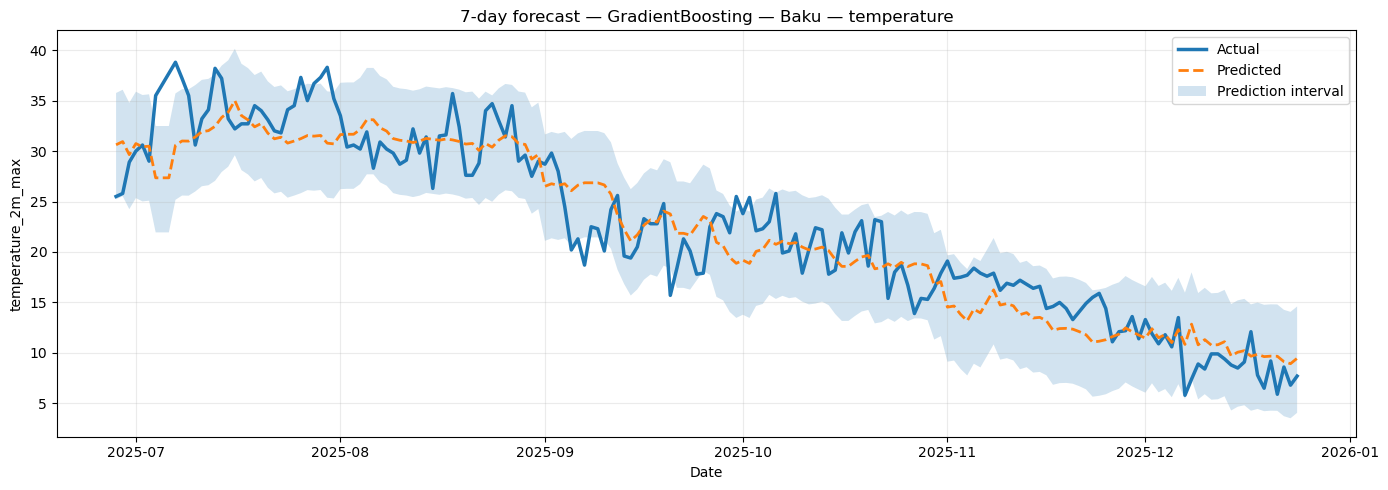

In [17]:
best_7d_name = results_7d.iloc[0]["model"]
print("Best 7-day model:", best_7d_name)

df_sup_7d, train_7d, test_7d_clean, y_test_7d_clean, preds_7d_clean, model_7d = train_best_horizon_model(
    df_input=df,
    horizon=7,
    split_date=split_date,
    model_name=best_7d_name
)

lower_7d, upper_7d, coverage_7d_df, overall_coverage_7d = horizon_interval_and_coverage(
    train_df=train_7d,
    test_df=test_7d_clean,
    y_test=y_test_7d_clean,
    preds=preds_7d_clean,
    model=model_7d,
    alpha=0.85
)

plot_7d_df = build_plot_df(
    test_df=test_7d_clean,
    y_test=y_test_7d_clean,
    preds=preds_7d_clean,
    lower=lower_7d,
    upper=upper_7d
)

print("7-day coverage:")
display(coverage_7d_df)
print("Overall 7-day coverage:", overall_coverage_7d)

plot_forecast_line(
    plot_df=plot_7d_df,
    city="Baku",
    target="temperature_2m_max",
    title=f"7-day forecast — {best_7d_name} — Baku — temperature",
    last_n=180
)

Best 28-day model: GradientBoosting
28-day coverage:


,target,coverage
0,temperature_2m_max,0.778042
1,precipitation_sum,0.823739
2,wind_speed_10m_max,0.777448
3,relative_humidity_2m_mean,0.833234
4,cloud_cover_mean,0.789318


Overall 28-day coverage: 0.8003560830860534


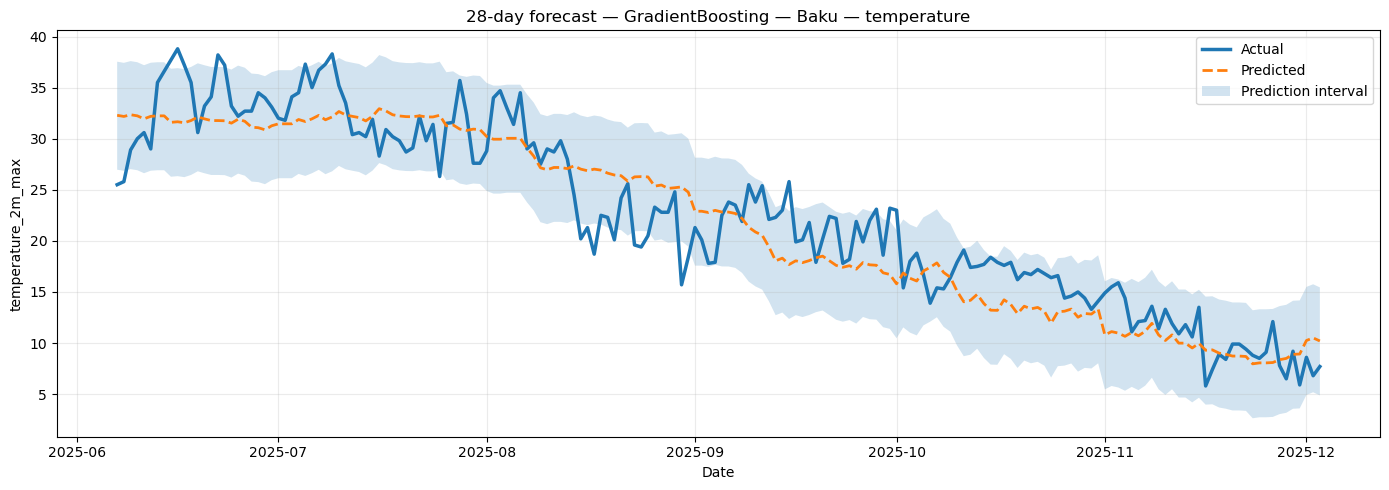

In [18]:
best_28d_name = results_28d.iloc[0]["model"]
print("Best 28-day model:", best_28d_name)

df_sup_28d, train_28d, test_28d_clean, y_test_28d_clean, preds_28d_clean, model_28d = train_best_horizon_model(
    df_input=df,
    horizon=28,
    split_date=split_date,
    model_name=best_28d_name
)

lower_28d, upper_28d, coverage_28d_df, overall_coverage_28d = horizon_interval_and_coverage(
    train_df=train_28d,
    test_df=test_28d_clean,
    y_test=y_test_28d_clean,
    preds=preds_28d_clean,
    model=model_28d,
    alpha=0.85
)

plot_28d_df = build_plot_df(
    test_df=test_28d_clean,
    y_test=y_test_28d_clean,
    preds=preds_28d_clean,
    lower=lower_28d,
    upper=upper_28d
)

print("28-day coverage:")
display(coverage_28d_df)
print("Overall 28-day coverage:", overall_coverage_28d)

plot_forecast_line(
    plot_df=plot_28d_df,
    city="Baku",
    target="temperature_2m_max",
    title=f"28-day forecast — {best_28d_name} — Baku — temperature",
    last_n=180
)